# Variance of Wolbachia-infected mosquitoes per household for the 4 single release scenarios.
## Abby Barlow, The University of Bath

Uses 'SSA_rel_com_fem_switch.jl' for the stochastic simulation of the community scale releases and 'SSA_rel_hhold_fem_switch.jl' for household scale releases which are called in 'Single_release_sep_file.jl'.

To use the already produced results see 'Initial_release_experiments.csv' for the required zip file names.

Import required libraries

In [1]:
### importing the required libraries
using CSV
using DataFrames
using Statistics
using Plots
using DataStructures
using Measures

Import required scripts to read and check data files

In [2]:
module Read
    include("Read_data_files.jl")
end

module Check
    include("Check_files_exist.jl")
end

Main.Check

### Key simulation parameters

JOB_ID defines the job run from the HPC and is used to identify each set of results. These are detailed in 'Initial_release_experiments.csv'.

gamma, rho, tau and alpha are the mosquito dispersal parameters.

num_simulations defines the number of simulation runs of the SSA for each result.

rel_type defines the release scale. 'relhhold' is for household scale releases and 'relcom' is for community scale releases.

In [3]:
### change this to the job id for the experiment you want to analyze
## or the name you want to give the folder where all the extracted data files will be stored
JOB_ID = 67133712
### make sure to write dispersal parameters as floats to keep file name consistent ###

## vary these for different dispersal scenarios
gamma = 0.15    # dispersal rate from release site to household
rho = 0.33      # rate visit the households
tau = 0.33      # rate leave the households
alpha = 0.1     # dispersal rate of females moving from household directly to another household

num_simulations = 100  # number of realisations of SSA to run, 10,000 is a good number for the paper
rel_type = "relhhold"  # release scale

"relhhold"

Parameter dictionary

In [4]:
fem_w0 = 0  # how many wildtypes and infected mosquitoes starting off with
male_w0 = 0
fem_m0 = 8
male_m0 = 8
# initialising the free pool of mosquitoes
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
phi = 0.85      # wolbachia fitness effect on birth rate
K = 30          # carrying capacity of mosquitoes per household
d = 12/100      # death rate of mosquitoes
k = 0.3         # larval density parameter
h = 0.19*100^k  # larval density parameter
b = 0.54        # per capita birth rate of mosquitoes (wildtypes)
H = 100         # number of households
u = 1           # vertical transmission probability
v = 1           # CI effect, proportion of non-viable offspring from infected male and wildtype female birth

rel_t = 150   # initial release time
delta_rel = 0 # time in days between releases, currently set to a single release inside the SSA code
## remember this is per household for the household releases so should use smaller release numbers
## currently set for household scale release
rel_size = 8 # total number of Wolbachia-infected mosquitoes released into the community

t_start = 0    
t_end = 1000   # start time and end time (days) of simulation

result_length = length(t_start:t_end) # number of time points to store results
weeks = round(Int,result_length/7)    # number of weeks to store results

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :delta_rel => delta_rel,
    :rel_size => rel_size,
    :gamma => gamma,
    :alpha => alpha,
    :rel_t => rel_t
)

Dict{Symbol, Real} with 24 entries:
  :b        => 0.54
  :alpha    => 0.1
  :rel_size => 8
  :gamma    => 0.15
  :m_free0  => 0
  :rho      => 0.33
  :t_start  => 0
  :h        => 0.756404
  :rel_t    => 150
  :male_w0  => 0
  :fem_m0   => 8
  :K        => 30
  :phi      => 0.85
  :fem_w0   => 0
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :male_m0  => 8
  ⋮         => ⋮

Covert dispersal parameters to strings to use in figure names when saving. Returns variances for each mosquito type in the household decomposed and combined.

In [29]:
alpha_str, gamma_str, rho_str, tau_str = Read.str_convert(alpha, gamma, rho, tau)

row_var_fem_m_h, row_var_male_m_h, row_var_fem_w_h, row_var_male_w_h, row_var_w_tot_h, row_var_m_tot_h = Check.var_hholds(alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size, rel_type, num_simulations, JOB_ID)

([0.0, 10.943443534353522, 12.592251185118524, 13.06388554855488, 13.119943504350413, 12.97506661666165, 13.25028421842184, 13.20836458645867, 13.22035114511452, 13.085061616161587  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 5.070479487948803, 5.40404216421641, 5.344572047204723, 5.341909190919084, 5.467943234323457, 5.543711481148115, 5.549486058605872, 5.682807280728087, 5.610526642664253  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  10.31007875787582, 10.346197779777976, 10.157916101610153, 10.500187128712867, 10.18067882788276, 10.006289588958898, 10.212292339233947, 10.548732063206293, 10.124687578757884, 10.213510861086132], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  4.331957195719578, 4.257069456945691, 4.201232913291324, 4.420886528652889, 4.243319921992188, 4.239932153215335, 4.1953794979497845, 4.327600510051025, 4.311058855885597, 4.2813384438443824], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

Reads in pre-processed data

In [5]:
var_df = CSV.read(joinpath("../Initial_paper_results", "var_hhold_all.csv"), DataFrame)

Row,week,row_var_w_tot_015,row_var_w_tot_033,row_var_w_tot_2,row_var_w_tot_h,row_var_fem_w_015,row_var_fem_w_033,row_var_fem_w_2,row_var_fem_w_h,row_var_male_w_015,row_var_male_w_033,row_var_male_w_2,row_var_male_w_h
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Unpacks the all varinace results

In [6]:
row_var_w_tot_015 = var_df[!, :row_var_w_tot_015]
row_var_w_tot_033 = var_df[!, :row_var_w_tot_033]
row_var_w_tot_2 = var_df[!, :row_var_w_tot_2]
row_var_w_tot_h = var_df[!, :row_var_w_tot_h]
row_var_fem_w_015 = var_df[!, :row_var_fem_w_015]
row_var_fem_w_033 = var_df[!, :row_var_fem_w_033]
row_var_fem_w_2 = var_df[!, :row_var_fem_w_2]
row_var_fem_w_h = var_df[!, :row_var_fem_w_h]
row_var_male_w_015 = var_df[!, :row_var_male_w_015]
row_var_male_w_033 = var_df[!, :row_var_male_w_033]
row_var_male_w_2 = var_df[!, :row_var_male_w_2]
row_var_male_w_h = var_df[!, :row_var_male_w_h]

143-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 4.257069456945691
 4.201232913291324
 4.420886528652889
 4.243319921992188
 4.239932153215335
 4.1953794979497845
 4.327600510051025
 4.311058855885597
 4.2813384438443824

In [9]:
days = collect(1:length(row_var_w_tot_015)) .* 7

143-element Vector{Int64}:
    7
   14
   21
   28
   35
   42
   49
   56
   63
   70
    ⋮
  945
  952
  959
  966
  973
  980
  987
  994
 1001

Produces figure for variance in total Wolbachia-infected population an the household

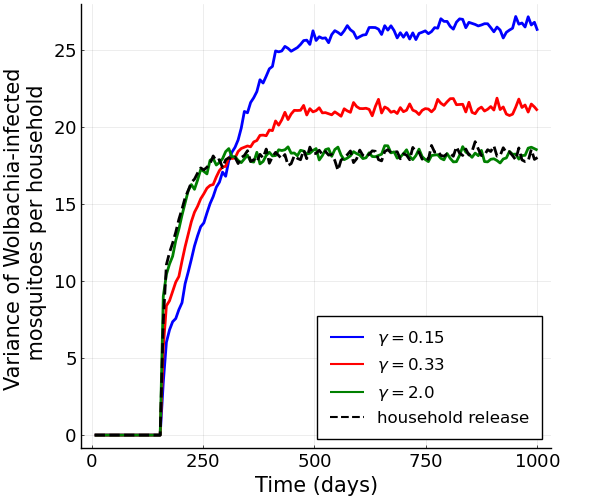

In [ ]:
pyplot() # using the pyplot backend for plotting

# plotting for gamma = 0.15
p=plot(days, row_var_w_tot_015, xlabel="Time (days)", ylabel="Variance of Wolbachia-infected \n mosquitoes per household",titlefont=font(14), label ="\$\\gamma=0.15\$",linecolor=:blue,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# plotting for gamma = 0.33
plot!(days, row_var_w_tot_033, label ="\$\\gamma=0.33\$", linecolor=:red,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# plotting for gamma = 2.0
plot!(days, row_var_w_tot_2, label ="\$\\gamma=2.0\$", linecolor=:green,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# plotting for household release
plot!(days, row_var_w_tot_h, label ="household release", linecolor=:black, linestyle=:dash,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# lengend requirements
plot!(size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2,
legendfont=font(12),
legend=:bottomright,
right_margin=10mm
)
#savefig(p, "variance_01_gammas_033_033_100__150_8_relhhold.pdf")
#plot!(legend=(0.6,0.8))
p

Produces figure for the variances of Wolbachia-infected males and females in the household.

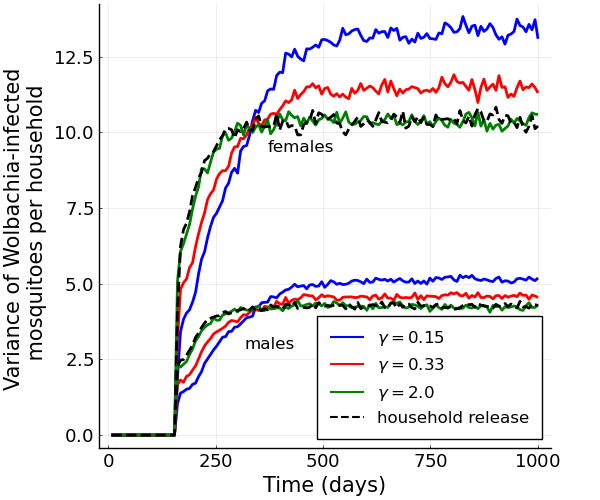

In [ ]:
pyplot()  # using the pyplot backend for plotting

# plotting for gamma = 0.15, females
p=plot(days, row_var_fem_w_015, xlabel="Time (days)", ylabel="Variance of Wolbachia-infected \n mosquitoes per household",titlefont=font(14), label ="\$\\gamma=0.15\$", linecolor=:blue,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# plotting for gamma = 0.33, females 
plot!(days, row_var_fem_w_033, label ="\$\\gamma=0.33\$", linecolor=:red,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# plotting for gamma = 2.0, females 
plot!(days, row_var_fem_w_2, label ="\$\\gamma=2.0\$", linecolor=:green,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# plotting for household release, females
plot!(days, row_var_fem_w_h, label ="household release", linecolor=:black, linestyle=:dash,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# plotting for gamma = 0.15, males 
plot!(days, row_var_male_w_015, label=false, linecolor=:blue,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# plotting for gamma = 0.33, males 
plot!(days, row_var_male_w_033, label=false, linecolor=:red,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# plotting for gamma = 2, males
plot!(days, row_var_male_w_2, label=false, linecolor=:green,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# plotting for household scale release, males
plot!(days, row_var_male_w_h, linecolor=:black, linestyle=:dash, label=false,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)

# lengend requirements
plot!(size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2,
legendfont=font(12),
legend=:bottomright,
right_margin=10mm
)

# adding annotations
annotate!(47*8, 3, text("males", :black, 12))
annotate!(56*8, 9.5, text("females", :black, 12))
#savefig(p, "variance_01_gammasfem_033_033_100__150_8_relhhold.pdf")
#plot!(legend=(0.6,0.8))
p

Saves variance data to be reused

In [34]:
# Convert all arrays to vectors (if they are matrices)
row_var_w_tot_015_vec = vec(row_var_w_tot_015)
row_var_w_tot_033_vec = vec(row_var_w_tot_033)
row_var_w_tot_2_vec   = vec(row_var_w_tot_2)
row_var_w_tot_h_vec   = vec(row_var_w_tot_h)

row_var_fem_w_015_vec = vec(row_var_fem_w_015)
row_var_fem_w_033_vec = vec(row_var_fem_w_033)
row_var_fem_w_2_vec   = vec(row_var_fem_w_2)
row_var_fem_w_h_vec   = vec(row_var_fem_w_h)

row_var_male_w_015_vec = vec(row_var_male_w_015)
row_var_male_w_033_vec = vec(row_var_male_w_033)
row_var_male_w_2_vec   = vec(row_var_male_w_2)
row_var_male_w_h_vec   = vec(row_var_male_w_h)

# Create a DataFrame with all data
df = DataFrame(
    week = 1:length(row_var_w_tot_015_vec),
    row_var_w_tot_015 = row_var_w_tot_015_vec,
    row_var_w_tot_033 = row_var_w_tot_033_vec,
    row_var_w_tot_2   = row_var_w_tot_2_vec,
    row_var_w_tot_h   = row_var_w_tot_h_vec,
    row_var_fem_w_015 = row_var_fem_w_015_vec,
    row_var_fem_w_033 = row_var_fem_w_033_vec,
    row_var_fem_w_2   = row_var_fem_w_2_vec,
    row_var_fem_w_h   = row_var_fem_w_h_vec,
    row_var_male_w_015 = row_var_male_w_015_vec,
    row_var_male_w_033 = row_var_male_w_033_vec,
    row_var_male_w_2   = row_var_male_w_2_vec,
    row_var_male_w_h   = row_var_male_w_h_vec,
)

# Save to CSV
#CSV.write("var_hhold_all.csv", df)


Row,week,row_var_w_tot_015,row_var_w_tot_033,row_var_w_tot_2,row_var_w_tot_h,row_var_fem_w_015,row_var_fem_w_033,row_var_fem_w_2,row_var_fem_w_h,row_var_male_w_015,row_var_male_w_033,row_var_male_w_2,row_var_male_w_h
,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
